# HW1-A. Wave Data and DataLoader

## About this notebook

This notebook is part of HW1 for the 50.039 Deep Learning course at the Singapore University of Technology and Design.

**Author:** Matthieu DE MARI (matthieu_demari@sutd.edu.sg)

**Version:** 1.0 (2026)

**Requirements:**
- Python 3
- Matplotlib
- Numpy
- Pandas
- PyTorch
- Torchmetrics

## 0. Imports and CUDA

In addition to the libraries mentioned above, you will need the *helper_functions.py* file, which contains a few additional functions that help make this notebook simpler for you (e.g. visualisation, test cases, etc.)

Please refrain from modifying said file, but feel free to have a look at it.

In [5]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 21.7 MB/s eta 0:00:0000:01


In [6]:
# Matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Numpy
import numpy as np
# Pandas
import pandas as pd
# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import BinaryAccuracy
# Helper functions (additional file)
from helper_functions import *

ModuleNotFoundError: No module named 'helper_functions'

<div class="alert alert-block alert-info">
<b>A note before we start:</b> While not necessary, you might want to run the code for this homework using GPU. It remains possible, however, to use CPU only.
</div>

In [2]:
# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## 1. Loading and Visualizing the Dataset

In this first section, we are going to load a dataset from the *'wave_dataset.xlsx'* file.

Feel free to have a look at this Excel file if you need.

The cells below will define the parameters of our dataset, and load the data from the file.

### About the Dataset

This dataset represents a **wave interference pattern**. The decision boundary between the two classes follows the mathematical equation:

$$\sin(\pi x_1) + \sin(\pi x_2) = 0$$

Points are classified as:
- **Class 0** (blue): where $\sin(\pi x_1) + \sin(\pi x_2) \leq 0$
- **Class 1** (red): where $\sin(\pi x_1) + \sin(\pi x_2) > 0$

In [3]:
# Dataset parameters
np.random.seed(2026)
min_val = -2
max_val = 2

In [4]:
# Load dataset from file
excel_file_path = 'wave_dataset.xlsx'
x1_list, x2_list, inputs, outputs = load_wave_dataset(excel_file_path=excel_file_path)

In [5]:
# Visualize data in arrays
print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)
print("Number of samples with class 0:", len(outputs) - sum(outputs))
print("Number of samples with class 1:", sum(outputs))

Input shape: (1200, 2)
Output shape: (1200,)
Number of samples with class 0: 605
Number of samples with class 1: 595


The visualization below shows the samples in the dataset, along with their ground truth class (red cross = Class 1, blue dot = Class 0). The dashed green line shows the true decision boundary.

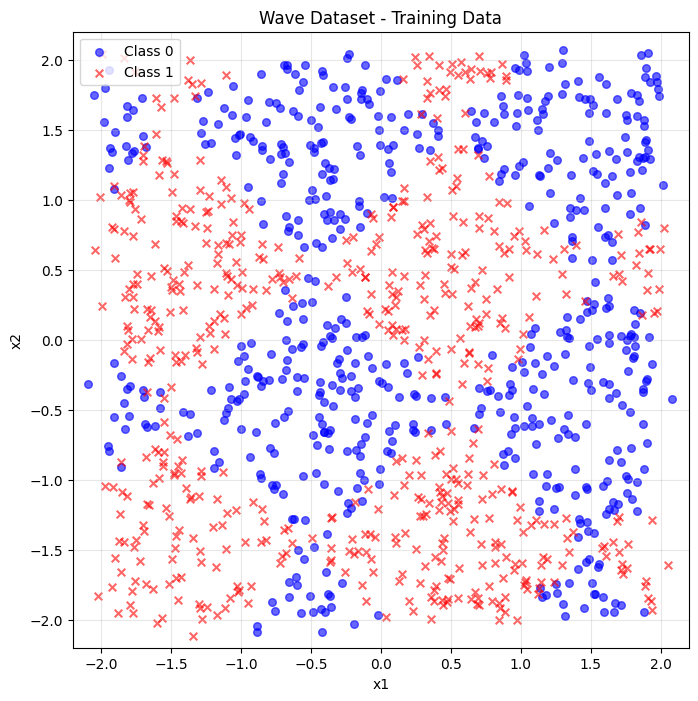

In [6]:
# Visualize the dataset
plot_wave_dataset(x1_list, x2_list, outputs, title="Wave Dataset - Training Data")

---

**Question 1:** Given the code executed above, describe the different elements of the Machine Learning problem that we are facing:

- **Task (T):** Can you describe the ML task behind this problem?
- **Dataset (D):** How many samples?
- **Inputs (I):** What are the inputs and what is the dimensionality of each input?
- **Outputs (O):** What are the possible output values?

Additionally, explain why a **linear classifier** (such as logistic regression) would fail on this decision boundary.

---

---

**Question 2:** The decision boundary follows $\sin(\pi x_1) + \sin(\pi x_2) = 0$.

- Describe geometrically what this boundary looks like. (Hint: think about where $\sin(\pi x_1) = -\sin(\pi x_2)$)
- How many separate regions does each class occupy in the range $[-2, 2] \times [-2, 2]$?
- Why does this pattern create diagonal stripes?

---

## 2. Writing a PyTorch Dataset Object

Now we would like to write a **PyTorch Dataset** object for our Machine Learning problem.

Have a look at the incomplete code below. There are several `None` variables that need to be replaced with the correct values.

Once you have figured out the correct values, you should be able to run the function `test_dataset_object()` below. It will produce test cases for you, and all should pass for this task to be considered resolved.

Your class is expected to have the following features:

- **Initialization (`__init__` method):** The dataset initializes by reading an Excel file (`wave_dataset.xlsx`) using Pandas `read_excel` function and stores it in the `dataframe` attribute.

- **Length method (`__len__` method):** This method should return the number of samples in the dataset.

- **Get item method (`__getitem__` method):** This method retrieves a single sample from the dataset at a given index `idx`. It should:
  - Extract the features `x1` and `x2` from the dataframe for the sample at index `idx`
  - Extract the target `y` from the dataframe
  - Convert features to PyTorch tensors of type `torch.float32`
  - Convert target to a PyTorch tensor of type `torch.float32`
  - Stack features into a single tensor `inputs` of shape `(2,)`
  - Return both the `inputs` tensor and the target tensor `y`

In [7]:
class WaveDataset(Dataset):
    def __init__(self):
        self.dataframe = pd.read_excel('wave_dataset.xlsx')
        
    def __len__(self):
        return None
    
    def __getitem__(self, idx):
        # Extract features and target from the dataframe at index idx
        x1 = None
        x2 = None
        y = None
        
        # Convert to PyTorch tensors
        x1 = torch.tensor(x1, dtype=torch.float32)
        x2 = torch.tensor(x2, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        
        # Stack features into a single input tensor
        # Combine x1 and x2 into a tensor of shape (2,)
        inputs = None
        
        return inputs, y

In [8]:
# Create our PyTorch Dataset object from the class above
pt_dataset = WaveDataset()

In [9]:
# Running test function for our dataset object
test_dataset_object(pt_dataset)

Testing WaveDataset Implementation

--- Test case 1: __getitem__ method ---
Drawing sample with index 100 from dataset...
Test case 1: FAILED - must be real number, not NoneType

--- Test case 2: __len__ method ---
Checking dataset length...
Test case 2: FAILED - 'NoneType' object cannot be interpreted as an integer

Some tests FAILED. Please review your implementation.


---

**Question 3:** Show the code for your `WaveDataset` class after you have correctly figured out how to replace the different `None` variables.

---

---

**Question 4:** Answer the following conceptual questions about the Dataset class:

- What information does the `__len__` method return? What would happen if it returned `0` instead?
- What would happen if `__getitem__` returned NumPy arrays instead of PyTorch tensors?
- Why do we convert the data to `torch.float32` specifically?

---

## 3. Writing a DataLoader Object

Our next task is to write a PyTorch **DataLoader** object. It will serve as a conveyor belt for our PyTorch Dataset object.

The DataLoader should:
- Form mini-batches of size **64**
- **Shuffle** the samples in the dataset

In [ ]:
# Define batch size
batch_size = None  # TODO: Set the batch size to 64

---

**Question 5:** Complete the DataLoader creation in the cell below. You need to:
- Pass the dataset object
- Set the batch size
- Enable shuffling

Show your code in your report.

---

In [ ]:
# Create DataLoader object
pt_dataloader = DataLoader(None)

In [ ]:
# Running test function for our dataloader object
test_dataloader_object(pt_dataloader)

---

**Question 6:** Answer the following conceptual questions about DataLoaders:

- Why is shuffling the dataset important during **training**?
- Should we shuffle during **evaluation/testing**? Why or why not?
- What is the advantage of using mini-batches instead of processing all samples at once (full batch) or one sample at a time (stochastic)?

---

## What's Next?

Our task continues in **Notebook HW1-B**, where we will implement a custom Gated Activation layer.